```{index} single: Pyomo; block
```
```{index} single: Pyomo; kernel library
```
```{index} single: conic optimization; exponential cones
```
```{index} single: solver; mosek
```
```{index} single: application; portfolio
```

# Extra material: Optimal Growth Portfolios with Risk Aversion

Among the reasons why Kelly was neglected by investors were high profile critiques by the most famous economist of the 20th Century, Paul Samuelson. Samuelson objected on several grounds, among them is a lack of risk aversion that results in large bets and risky short term behavior, and that Kelly's result is applicable to only one of many utility functions that describe investor preferences. The controversy didn't end there, however, as other academic economists, including Harry Markowitz, and practitioners found ways to adapt the Kelly criterion to investment funds.

This notebook presents solutions to Kelly's problem for optimal growth portfolios using exponential cones. A significant feature of this notebook is the the inclusion of a risk constraints recently proposed by Boyd and coworkers. These notes are based on recent papers such as Cajas (2021), Busseti, Ryu and Boyd (2016), Fu, Narasimhan, and Boyd (2017). Additional bibliographic notes are provided at the end of the notebook.

In [1]:
import sys, os

if "google.colab" in sys.modules:
    %pip install -q pyomo idaes-pse yfinance
    !idaes get-extensions --to ./bin
    os.environ["PATH"] += os.pathsep + os.path.abspath("bin")
    solver = "ipopt"
else:
    solver = "mosek_direct"

import pyomo.kernel as pmo
import pyomo.environ as pyo
SOLVER = pmo.SolverFactory(solver)
assert SOLVER.available(), f"Solver {solver} is not available."


## Financial Data

We begin by reading historical prices for a selected set of trading symbols using [yfinance](https://github.com/ranaroussi/yfinance). 

While it would be interesting to include an international selection of financial indices and assets, differences in trading and bank holidays would involve more elaborate coding. For that reason, the following cell has been restricted to indices and assets trading in U.S. markets.

For the saved example we use 1 January 2023 through 31 December 2025; the download's end date is exclusive. Set `USE_CURRENT_WINDOW` to true to use the most recent three years instead. These are in-sample portfolio calculations, not an out-of-sample performance test. Even for fixed dates, adjusted historical prices can change at the provider.

We request `Adj Close` explicitly with `auto_adjust=False`, validate every requested series, and stop on missing or invalid prices rather than filling gaps or silently dropping dates. The download remains in memory and its provenance is printed below. Install `yfinance` locally with `%pip install yfinance` if needed; the Colab preamble installs it automatically.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime
import yfinance as yf

def validate_prices(prices, tickers, start, end, min_observations=60):
    """Check the common price table before calculating returns; never fill gaps."""
    if not tickers or len(tickers) != len(set(tickers)):
        raise ValueError("Request a nonempty list of distinct tickers.")
    if not isinstance(prices, pd.DataFrame) or prices.empty:
        raise ValueError("No prices returned. Check the dates, tickers and connection.")
    if prices.columns.has_duplicates:
        raise ValueError("The price table has duplicate ticker columns.")
    missing = sorted(set(tickers) - set(prices.columns))
    if missing:
        raise ValueError(f"Missing requested tickers: {missing}")
    if not isinstance(prices.index, pd.DatetimeIndex) or prices.index.hasnans:
        raise ValueError("Prices need valid trading dates as a DatetimeIndex.")
    if prices.index.has_duplicates or not prices.index.is_monotonic_increasing:
        raise ValueError("Trading dates must be unique and in increasing order.")
    if prices.index.tz is not None:
        raise ValueError("Use daily trading dates without a time zone.")
    if not (pd.Timestamp(start) <= prices.index.min()
            <= prices.index.max() < pd.Timestamp(end)):
        raise ValueError("Prices fall outside the requested [start, end) window.")
    if len(prices) < min_observations:
        raise ValueError(f"Need at least {min_observations} price observations; "
                         f"received {len(prices)}. Choose a longer window.")
    try:
        prices = prices.loc[:, tickers].astype(float).copy()
    except (TypeError, ValueError) as exc:
        raise ValueError("Every requested price must be numeric.") from exc
    invalid = ~np.isfinite(prices) | (prices <= 0)
    if invalid.to_numpy().any():
        counts = invalid.sum()
        dates = prices.index[invalid.any(axis=1)].strftime('%Y-%m-%d').tolist()
        raise ValueError(f"Missing or invalid prices by ticker: "
                         f"{counts[counts > 0].to_dict()}; "
                         f"first affected dates: {dates[:5]}. No gaps were filled.")
    return prices


def download_prices(tickers, start, end):
    """Download adjusted closes into memory and validate the result."""
    raw = yf.download(tickers, start=start, end=end, progress=False,
                      auto_adjust=False, keepna=True, threads=False,
                      group_by='column', multi_level_index=True)
    if raw is None or raw.empty or 'Adj Close' not in raw.columns:
        raise ValueError("No adjusted closing prices returned. Check the "
                         "connection, dates and tickers, then retry.")
    return validate_prices(raw['Adj Close'], tickers, start, end)

In [3]:
# symbols as used by Yahoo Finance
symbols = {
    # selected indices
    "^GSPC": "S&P 500",
    "^IXIC": "Nasdaq",
    "^DJI": "Dow Jones Industrial",
    "^RUT": "Russell 2000",
    # selected stocks
    "AXP": "American Express",
    "AMGN": "Amgen",
    "AAPL": "Apple",
    "BA": "Boeing",
    "CAT": "Caterpillar",
    "CVX": "Chevron",
    "JPM": "JPMorgan Chase",
    "MCD": "McDonald's",
    "MMM": "3M",
    "MSFT": "Microsoft",
    "PG": "Procter & Gamble",
    "XOM": "ExxonMobil",
}

USE_CURRENT_WINDOW = False
start, end = datetime.date(2023, 1, 1), datetime.date(2026, 1, 1)
if USE_CURRENT_WINDOW:
    end = datetime.date.today()
    start = end - datetime.timedelta(days=3 * 365)

S = download_prices(list(symbols), start, end)
retrieved_at = datetime.datetime.now(datetime.timezone.utc).isoformat(timespec="seconds")
print(f"Yahoo Finance via yfinance {yf.__version__}; retrieved {retrieved_at}")
print(f"Requested window: {start} <= date < {end}")
print(f"Returned window: {S.index[0].date()} to {S.index[-1].date()}")
print(f"Series ({len(S.columns)}): {', '.join(S.columns)}")
print("Price field: Adj Close; auto_adjust=False; no missing prices filled or removed")

# The first date has no preceding observation; all subsequent gross returns are retained.
R = (S / S.shift(1)).iloc[1:]
print(f"Observations: {len(S)} prices and {len(R)} gross returns per series")


Yahoo Finance via yfinance 1.7.0; retrieved 2026-09-13T17:28:09+00:00
Requested window: 2023-01-01 <= date < 2026-01-01
Returned window: 2023-01-03 to 2025-12-31
Series (16): ^GSPC, ^IXIC, ^DJI, ^RUT, AXP, AMGN, AAPL, BA, CAT, CVX, JPM, MCD, MMM, MSFT, PG, XOM
Price field: Adj Close; auto_adjust=False; no missing prices filled or removed
Observations: 752 prices and 751 gross returns per series


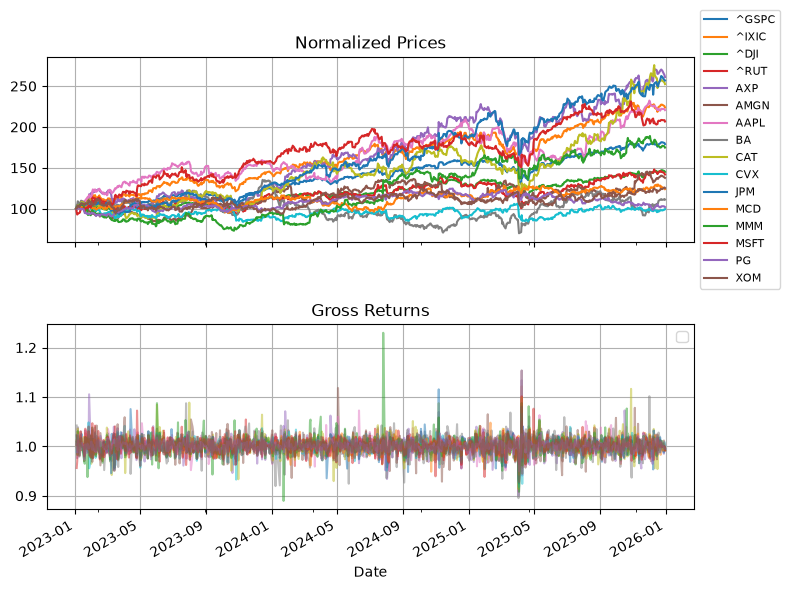

In [5]:
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
S.divide(S.iloc[0] / 100).plot(ax=ax[0], grid=True, title="Normalized Prices")
ax[0].legend(loc="center left", bbox_to_anchor=(1.0, 0.5), prop={"size": 8})
R.plot(ax=ax[1], grid=True, title="Gross Returns", alpha=0.5).legend([])
plt.tight_layout()
plt.show()

## Portfolio Design for Optimal Growth

### Model

Here we are examining a set $N$ of financial assets trading in efficient markets. The historical record consists of a matrix $R \in \mathbb{R}^{T\times N}$ of gross returns where $T$ is the number of observations. 

The weights $w_n \geq 0$ for $n\in N$ denote the fraction of the portfolio invested in asset $n$. Any portion of the portfolio not invested in traded assets is assumed to have a gross risk-free return $R_f = 1 + r_f$, where $r_f$ is the return on a risk-free asset.

Assuming the gross returns are independent and identically distributed random variables, and the historical data set is representative of future returns, the investment model becomes

$$
\begin{align}
\max_{w_n \geq 0}\quad & \frac{1}{T} \sum_{t\in T} \log(R_t) \\
\text{s.t.}\quad \\
& R_t = R_f + \sum_{n\in N} w_n (R_{t, n} - R_f) & \forall t\in T\\
\end{align}
$$

Note this formulation allows the sum of weights $\sum_{n\in N} w_n$ to be greater than one. In that case the investor would be investing more than the value of the portfolio in traded assets. In other words the investor would be creating a leveraged portfolio by borrowing money at a rate $R_f$. To incorporate a constraint on the degree of leveraging, we introduce a constraint

$$\sum_{n\in N} w_n \leq E_M$$

where $E_M$ is the "equity multiplier." A value $E_M \leq 1$ restricts the total investment to be less than or equal to the equity available to the investor. A value $E_M > 1$ allows the investor to leverage the available equity by borrowing money at a gross rate $R_f = 1 + r_f$. 

Using techniques demonstrated in other examples, this model can be reformulated with exponential cones.

$$
\begin{align}
\max_{w_n}\quad & \frac{1}{T} \sum_{t\in T} q_t \\
\text{s.t.}\quad 
& (R_f + \sum_{n\in N}w_n (R_{t,n} - R_f), 1, q_t) \in K_{exp} & \forall t \in T \\
& \sum_{n\in N} w_n \leq E_M \\
& w_n \geq 0  & \forall n\in N \\
\end{align} 
$$

For the risk constrained case, we consider a constraint

$$\mathbb{E}[R^{-\lambda}] \leq R_f^{-\lambda}$$

where $\lambda$ is a risk aversion parameter. Assuming the historical returns are equiprobable 

$$\frac{1}{T} \sum_{t\in T} R_t^{-\lambda} \leq R_f^{-\lambda}$$

The risk constraint is satisfied for any $w_n$ if the risk aversion parameter $\lambda=0$. For any value $\lambda > 0$ the risk constraint has a feasible solution $w_n=0$ for all $n \in N$. Recasting as a sum of exponentials,

$$\frac{1}{T} \sum_{t\in T} e^{- \lambda\log(R_t)} \leq R_f^{-\lambda}$$

Using the $q_t \leq \log(R_t)$ as used in the examples above, and $u_t \geq e^{- \lambda q_t}$, we get the risk constrained model optimal log growth. 

Given a risk-free rate of return $R_f$, a maximum equity multiplier $E_M$, and value $\lambda \geq 0$ for the risk aversion, risk constrained Kelly portfolio is given the solution to

$$
\begin{align}
\max_{w_n, q_t, u_t}\quad & \frac{1}{T} \sum_{t\in T} q_t \\
\text{s.t.}\quad 
& \frac{1}{T} \sum_{t\in T} u_t \leq R_f^{-\lambda} \\
& (u_t, 1, -\lambda q_t) \in K_{exp} & \forall t\in T \\
& (R_f + \sum_{n\in N}w_n (R_{t,n} - R_f), 1, q_t) \in K_{exp} & \forall t \in T \\
& \sum_{n\in N} w_n \leq E_M \\
& w_n \geq 0 & \forall n \in N \\
\end{align}
$$

The following cells demonstrate an implementation of the model using the Pyomo kernel library and Mosek solver.

### Pyomo Implementation

The Pyomo implementation for the risk-constrained Kelly portfolio accepts three parameters, the risk-free gross returns $R_f$, the maximum equity multiplier, and the risk-aversion parameter.


Risk Free Return = 0.00 %
Equity Multiplier Limit = 1.00000
Risk Aversion = 10.00000

Portfolio
^GSPC    S&P 500                  0.00 %
^IXIC    Nasdaq                   0.00 %
^DJI     Dow Jones Industrial     0.00 %
^RUT     Russell 2000             0.00 %
AXP      American Express        49.52 %
AMGN     Amgen                    0.00 %
AAPL     Apple                    0.00 %
BA       Boeing                   0.00 %
CAT      Caterpillar             26.62 %
CVX      Chevron                  0.00 %
JPM      JPMorgan Chase          23.86 %
MCD      McDonald's               0.00 %
MMM      3M                       0.00 %
MSFT     Microsoft                0.00 %
PG       Procter & Gamble         0.00 %
XOM      ExxonMobil               0.00 %
         Risk Free                0.00 %

Annualized return = 38.73 %

2025-12-31 00:00:00 

^GSPC 179.007573
^IXIC 223.760797
^DJI  145.046930
^RUT  141.764289
AXP   261.017809
AMGN  137.681482
AAPL  220.645511
BA    111.121345
CAT   252.404372
C

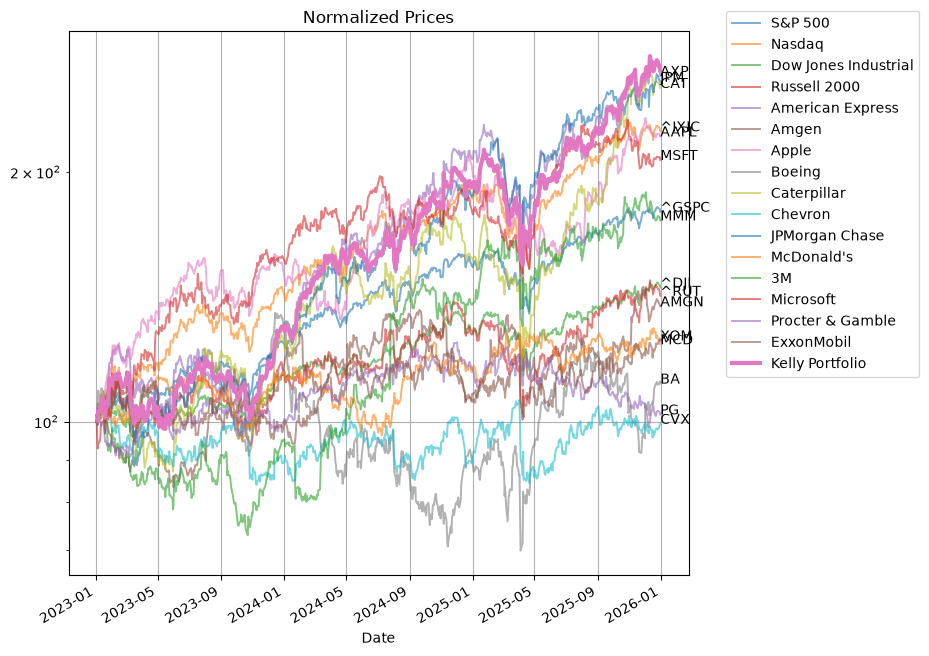

In [6]:
def kelly_portfolio(R, Rf=1, EM=1, lambd=0):
    m = pmo.block()

    # return parameters with the model
    m.Rf = Rf
    m.EM = EM
    m.lambd = lambd

    # index lists
    m.T = R.index
    m.N = R.columns

    # decision variables
    m.q = pmo.variable_dict({t: pmo.variable() for t in m.T})
    m.w = pmo.variable_dict({n: pmo.variable(lb=0) for n in m.N})

    # objective
    m.ElogR = pmo.objective(sum(m.q[t] for t in m.T) / len(m.T), sense=pmo.maximize)

    # conic constraints on return
    m.R = pmo.expression_dict(
        {
            t: pmo.expression(Rf + sum(m.w[n] * (R.loc[t, n] - Rf) for n in m.N))
            for t in m.T
        }
    )
    m.c = pmo.block_dict(
        {t: pmo.conic.primal_exponential.as_domain(m.R[t], 1, m.q[t]) for t in m.T}
    )

    # risk constraints
    m.u = pmo.variable_dict({t: pmo.variable() for t in m.T})
    m.u_sum = pmo.constraint(sum(m.u[t] for t in m.T) / len(m.T) <= Rf ** (-lambd))
    m.r = pmo.block_dict(
        {
            t: pmo.conic.primal_exponential.as_domain(m.u[t], 1, -lambd * m.q[t])
            for t in m.T
        }
    )

    # equity multiplier constraint
    m.w_sum = pmo.constraint(sum(m.w[n] for n in m.N) <= EM)

    results = SOLVER.solve(m)
    pyo.assert_optimal_termination(results)

    return m


def kelly_report(m):
    s = f"""
Risk Free Return = {100*(np.exp(252*np.log(m.Rf)) - 1):0.2f} %
Equity Multiplier Limit = {m.EM:0.5f}
Risk Aversion = {m.lambd:0.5f}

Portfolio
"""
    s += "\n".join([f"{n:8s} {symbols[n]:20s}  {100*m.w[n]():7.2f} %" for n in m.N])
    s += f"""
{'':8s} {'Risk Free':20s}  {100*(1 - sum(m.w[n]() for n in R.columns)):7.2f} %

Annualized return = {100*(np.exp(252*m.ElogR()) - 1):0.2f} %
"""
    print(s)

    df = pd.DataFrame(pd.Series([m.R[t]() for t in m.T]), columns=["Kelly Portfolio"])
    df.index = m.T

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    S.divide(S.iloc[0] / 100).plot(
        ax=ax, logy=True, grid=True, title="Normalized Prices", alpha=0.6, lw=1.4
    )
    df.cumprod().multiply(100).plot(ax=ax, lw=3, grid=True)
    ax.legend(
        [symbols[n] for n in m.N] + ["Kelly Portfolio"], bbox_to_anchor=(1.05, 1.05)
    )

    d = S.index[-1]
    print(d, "\n")

    for n in m.N:
        y = 100 * S[n].iloc[-1] / S[n].iloc[0]
        print(f"{n:5} {100 * S[n].iloc[-1] / S[n].iloc[0]:8.6f}")
        ax.text(d, y, n)


# parameter values
Rf = np.exp(np.log(1.0) / 252)
EM = 1
lambd = 10

m = kelly_portfolio(R, Rf, EM, lambd)
kelly_report(m)

In [8]:
S.head()

Ticker,^GSPC,^IXIC,^DJI,^RUT,AXP,AMGN,AAPL,BA,CAT,CVX,JPM,MCD,MMM,MSFT,PG,XOM
Date,,,,,,,,,,,,,,,,
2023-01-03,3824.139893,10386.980469,33136.371094,1750.729980,140.588959,232.962982,122.876740,195.389999,225.586624,149.220352,123.735184,241.869232,90.323952,232.510559,137.454971,94.180977
2023-01-04,3852.969971,10458.759766,33269.769531,1772.540039,143.857147,235.402588,124.144135,203.639999,227.928619,147.633728,124.889023,241.924088,92.300491,222.339767,138.053482,94.455093
2023-01-05,3808.100098,10305.240234,32930.078125,1753.189941,140.414612,237.601776,122.827606,204.990005,226.908722,150.292389,124.861343,239.883606,90.685333,215.750137,136.339493,96.568459
2023-01-06,3895.080078,10569.290039,33630.609375,1792.800049,144.000977,245.027344,127.346947,213.000000,235.011246,151.424484,127.250648,246.572449,93.458405,218.292831,139.586136,97.735634
2023-01-09,3892.090088,10635.650391,33517.648438,1795.910034,144.221512,240.504303,127.867661,208.570007,232.895889,150.240952,126.724808,244.541061,93.510025,220.418213,137.881134,95.914101


### Effects of the Risk-Aversion Parameter

In [9]:
lambd = 10 ** np.linspace(0, 3)
results = [kelly_portfolio(R, Rf=1, EM=1, lambd=_) for _ in lambd]

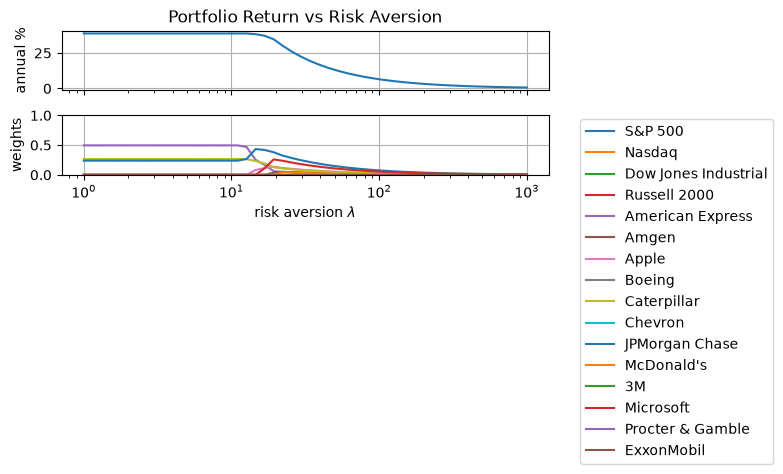

In [10]:
fig, ax = plt.subplots(2, 1, figsize=(8, 4), sharex=True)
ax[0].semilogx(
    [m.lambd for m in results], [100 * (np.exp(252 * m.ElogR()) - 1) for m in results]
)
ax[0].set_title("Portfolio Return vs Risk Aversion")
ax[0].set_ylabel("annual %")
ax[0].grid(True)

ax[1].semilogx(
    [m.lambd for m in results], [[m.w[n]() for n in R.columns] for m in results]
)
ax[1].set_ylabel("weights")
ax[1].set_xlabel(r"risk aversion $\lambda$")
ax[1].legend([symbols[n] for n in m.N], bbox_to_anchor=(1.05, 1.05))
ax[1].grid(True)
ax[1].set_ylim(0, EM)
plt.tight_layout()
plt.show()

### Effects of the Equity Multiplier Parameter

In [11]:
EM = np.linspace(0.0, 2.0)
results = [kelly_portfolio(R, Rf=1, EM=_, lambd=10) for _ in EM]

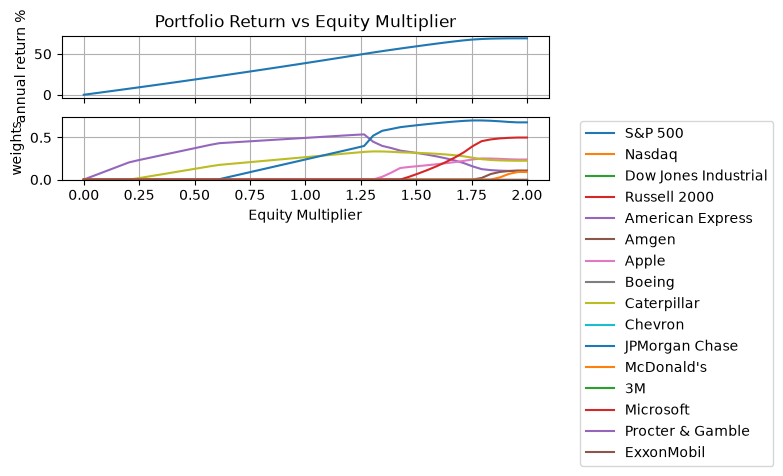

In [12]:
fig, ax = plt.subplots(2, 1, figsize=(8, 4), sharex=True)
ax[0].plot(
    [m.EM for m in results], [100 * (np.exp(252 * m.ElogR()) - 1) for m in results]
)
ax[0].set_title("Portfolio Return vs Equity Multiplier")
ax[0].set_ylabel("annual return %")
ax[0].grid(True)

ax[1].plot([m.EM for m in results], [[m.w[n]() for n in R.columns] for m in results])
ax[1].set_ylabel("weights")
ax[1].set_xlabel("Equity Multiplier")
ax[1].legend([symbols[n] for n in m.N], bbox_to_anchor=(1.05, 1.05))
ax[1].grid(True)
ax[1].set_ylim(
    0,
)
plt.tight_layout()
plt.show()

### Effect of Risk-free Interest Rate

In [13]:
Rf = np.exp(np.log(1 + np.linspace(0, 0.20)) / 252)
results = [kelly_portfolio(R, Rf=_, EM=1, lambd=10) for _ in Rf]

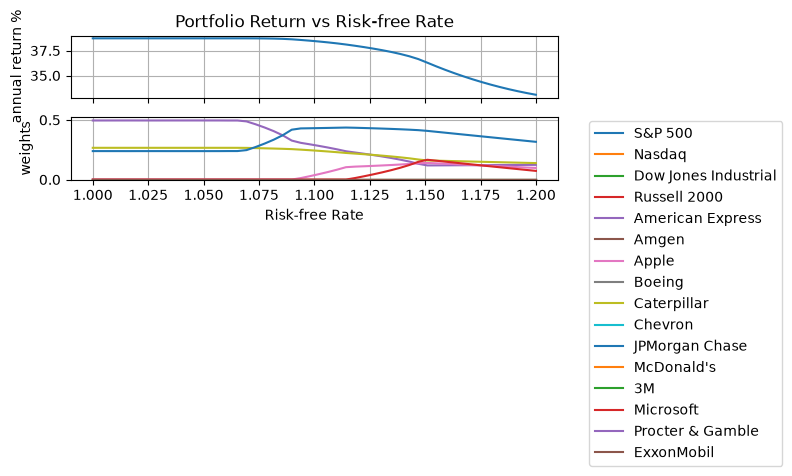

In [14]:
fig, ax = plt.subplots(2, 1, figsize=(8, 4), sharex=True)
Rf = np.exp(252 * np.log(np.array([_.Rf for _ in results])))
ax[0].plot(Rf, [100 * (np.exp(252 * m.ElogR()) - 1) for m in results])
ax[0].set_title("Portfolio Return vs Risk-free Rate")
ax[0].set_ylabel("annual return %")
ax[0].grid(True)

ax[1].plot(Rf, [[m.w[n]() for n in R.columns] for m in results])
ax[1].set_ylabel("weights")
ax[1].set_xlabel("Risk-free Rate")
ax[1].legend([symbols[n] for n in m.N], bbox_to_anchor=(1.05, 1.05))
ax[1].grid(True)
ax[1].set_ylim(
    0,
)
plt.tight_layout()
plt.show()

## Extensions

1. The examples cited in this notebook assume knowledge of the probability mass distribution. Recent work by Sun and Boyd (2018) and Hsieh (2022) suggest models for finding investment strategies for cases where the distributions are not perfectly known. They call the "distributional robust Kelly gambling." A useful extension to this notebook would be to demonstrate a robust solution to one or more of the examples.

## Bibliographic Notes

> Thorp, E. O. (2017). A man for all markets: From Las Vegas to wall street, how i beat the dealer and the market. Random House.

> Thorp, E. O. (2008). The Kelly criterion in blackjack sports betting, and the stock market. In Handbook of asset and liability management (pp. 385-428). North-Holland. https://www.palmislandtraders.com/econ136/thorpe_kelly_crit.pdf

> MacLean, L. C., Thorp, E. O., & Ziemba, W. T. (2010). Good and bad properties of the Kelly criterion. Risk, 20(2), 1.  https://www.stat.berkeley.edu/~aldous/157/Papers/Good_Bad_Kelly.pdf

> MacLean, L. C., Thorp, E. O., & Ziemba, W. T. (2011). The Kelly capital growth investment criterion: Theory and practice (Vol. 3). world scientific. https://www.worldscientific.com/worldscibooks/10.1142/7598#t=aboutBook

> Carta, A., & Conversano, C. (2020). Practical Implementation of the Kelly Criterion: Optimal Growth Rate, Number of Trades, and Rebalancing Frequency for Equity Portfolios. Frontiers in Applied Mathematics and Statistics, 6, 577050. https://www.frontiersin.org/articles/10.3389/fams.2020.577050/full

The utility of conic optimization to solve problems involving log growth is more recent. Here are some representative papers.

> Cajas, D. (2021). Kelly Portfolio Optimization: A Disciplined Convex Programming Framework. Available at SSRN 3833617. https://papers.ssrn.com/sol3/papers.cfm?abstract_id=3833617

> Busseti, E., Ryu, E. K., & Boyd, S. (2016). Risk-constrained Kelly gambling. The Journal of Investing, 25(3), 118-134. https://arxiv.org/pdf/1603.06183.pdf

> Fu, A., Narasimhan, B., & Boyd, S. (2017). CVXR: An R package for disciplined convex optimization. arXiv preprint arXiv:1711.07582. https://arxiv.org/abs/1711.07582

> Sun, Q., & Boyd, S. (2018). Distributional robust Kelly gambling. arXiv preprint arXiv: 1812.10371. https://web.stanford.edu/~boyd/papers/pdf/robust_kelly.pdf

The recent work by CH Hsieh extends these concepts in important ways for real-world implementation.

> Hsieh, C. H. (2022). On Solving Robust Log-Optimal Portfolio: A Supporting Hyperplane Approximation Approach. arXiv preprint arXiv:2202.03858. https://arxiv.org/pdf/2202.03858
